In [51]:
import pandas as pd
df = pd.read_csv("owid-covid-data.csv")
print(df)

       iso_code continent     location       date  total_cases  new_cases  \
0           AFG      Asia  Afghanistan   1/5/2020          0.0        0.0   
1           AFG      Asia  Afghanistan   1/6/2020          0.0        0.0   
2           AFG      Asia  Afghanistan   1/7/2020          0.0        0.0   
3           AFG      Asia  Afghanistan   1/8/2020          0.0        0.0   
4           AFG      Asia  Afghanistan   1/9/2020          0.0        0.0   
...         ...       ...          ...        ...          ...        ...   
429430      ZWE    Africa     Zimbabwe  7/31/2024     266386.0        0.0   
429431      ZWE    Africa     Zimbabwe   8/1/2024     266386.0        0.0   
429432      ZWE    Africa     Zimbabwe   8/2/2024     266386.0        0.0   
429433      ZWE    Africa     Zimbabwe   8/3/2024     266386.0        0.0   
429434      ZWE    Africa     Zimbabwe   8/4/2024     266386.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  

In [52]:
print(df.head())

  iso_code continent     location      date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  1/5/2020          0.0        0.0   
1      AFG      Asia  Afghanistan  1/6/2020          0.0        0.0   
2      AFG      Asia  Afghanistan  1/7/2020          0.0        0.0   
3      AFG      Asia  Afghanistan  1/8/2020          0.0        0.0   
4      AFG      Asia  Afghanistan  1/9/2020          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN                  37.746

In [53]:
print(df.columns)

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [54]:
print(df.isnull().sum())

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64


In [55]:
df['date'] = pd.to_datetime(df['date'])

In [56]:
countries = ['Kenya','India','United States','China']
df = df[df['location'].isin(countries)]

In [58]:
df =df.dropna(subset=['total_cases'])

In [59]:
df = df.fillna(0)

In [60]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6696 entries, 73670 to 405124
Data columns (total 67 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   iso_code                                    6696 non-null   object        
 1   continent                                   6696 non-null   object        
 2   location                                    6696 non-null   object        
 3   date                                        6696 non-null   datetime64[ns]
 4   total_cases                                 6696 non-null   float64       
 5   new_cases                                   6696 non-null   float64       
 6   new_cases_smoothed                          6696 non-null   float64       
 7   total_deaths                                6696 non-null   float64       
 8   new_deaths                                  6696 non-null   float64       
 9   new_dea

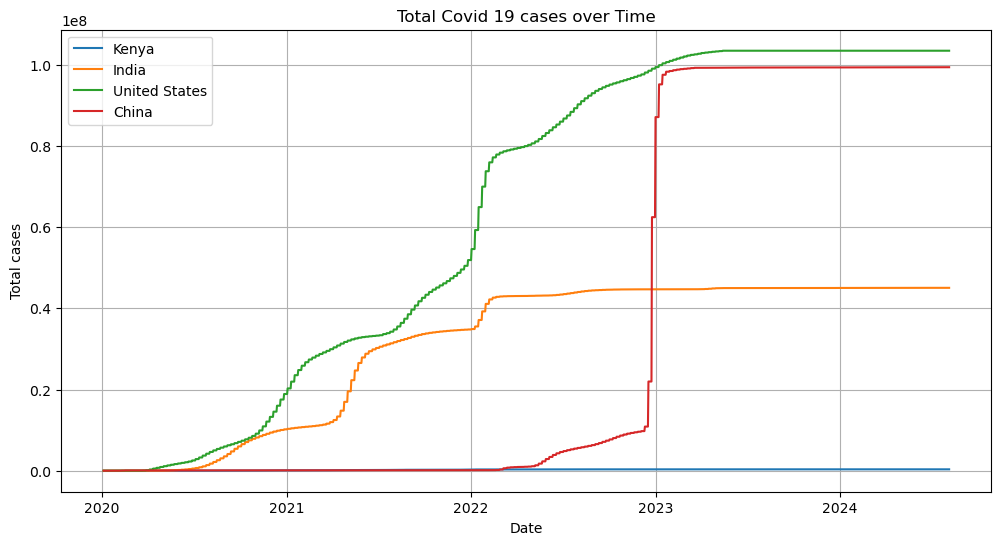

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
for country in countries:
    subset=df[df['location'] ==country]
    plt.plot(subset['date'],subset['total_cases'],label=country)
plt.title("Total Covid 19 cases over Time")
plt.xlabel("Date")
plt.ylabel("Total cases")
plt.legend()
plt.grid()
plt.show()

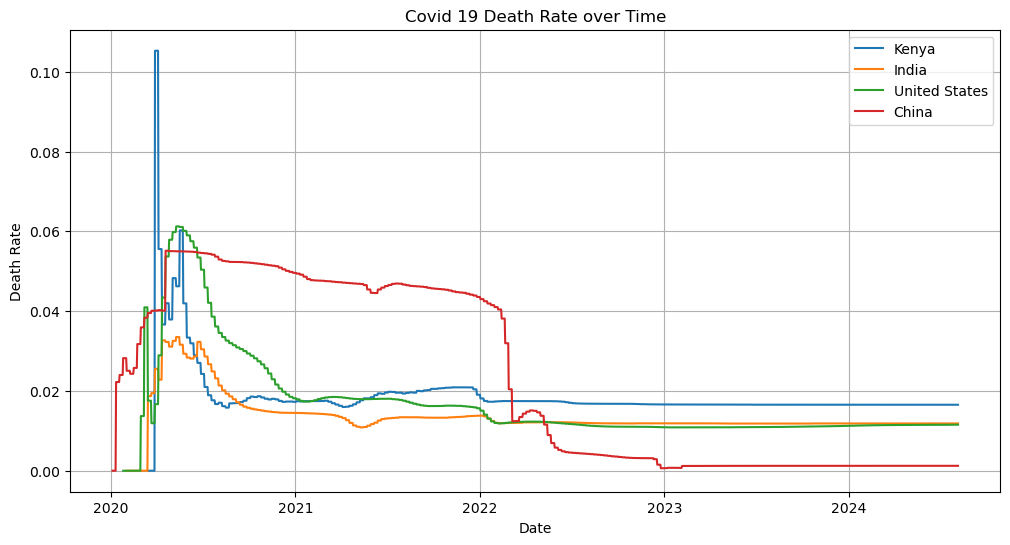

In [62]:
df['death_rate'] = df['total_deaths'] / df['total_cases']
plt.figure(figsize=(12,6))
for country in countries:
    subset=df[df['location'] ==country]
    plt.plot(subset['date'],subset['death_rate'],label=country)
plt.title("Covid 19 Death Rate over Time")
plt.xlabel("Date")
plt.ylabel("Death Rate")
plt.legend()
plt.grid()
plt.show()

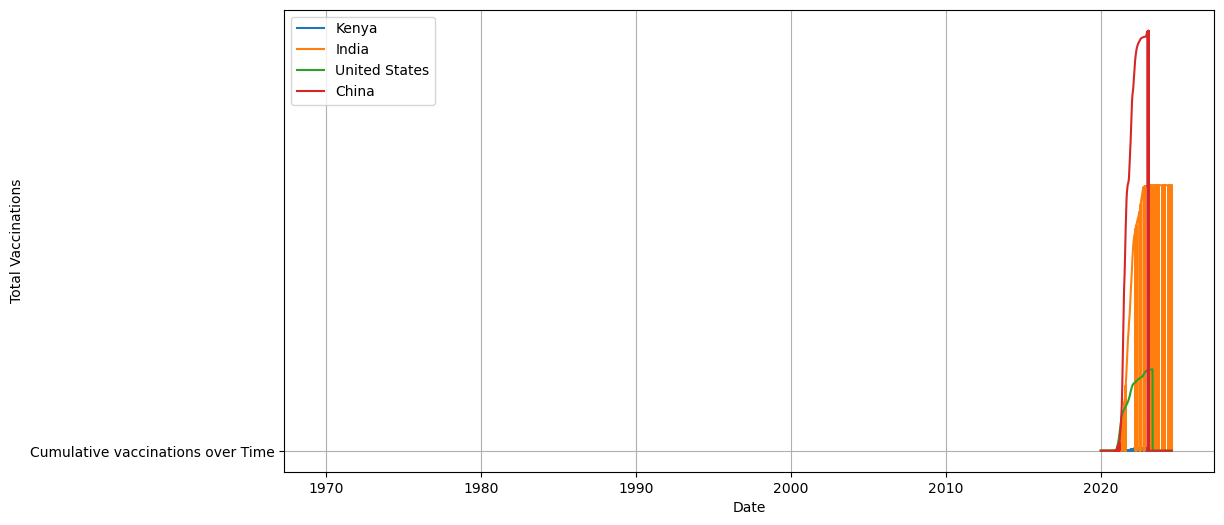

In [65]:
plt.figure(figsize=(12,6))
for country in countries:
    subset = df[df['location'] ==country]
    plt.plot(subset['date'],subset['total_vaccinations'],label=country)
plt.plot("Cumulative vaccinations over Time")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.legend()
plt.grid()
plt.show()

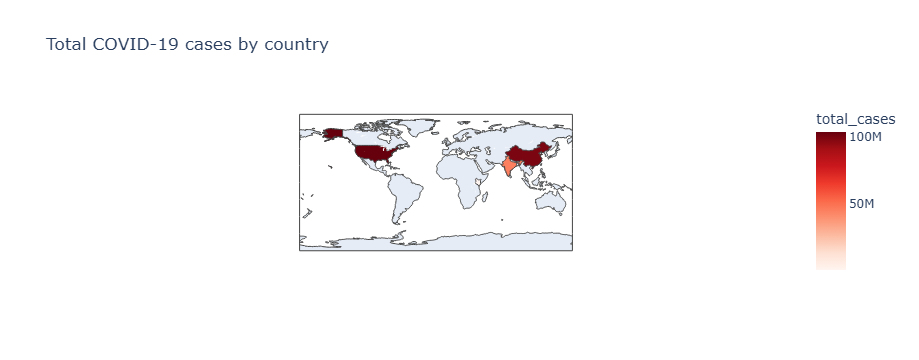

In [70]:
import plotly.express as px

latest = df[df['date'] == df['date'].max()]
latest = latest[latest['iso_code'].apply(lambda x: isinstance(x, str))]

fig = px.choropleth(latest,
                    locations="iso_code",
                    color="total_cases",
                    hover_name="location",  
                    title="Total COVID-19 cases by country",
                    color_continuous_scale="Reds") 
fig.show()

In [ ]:
Key insights
United States had the highest total COVID-19 cases and fastest early vaccine rollout.

India experienced major case surges, especially in mid-2021.

Kenya had fewer total cases but a relatively higher death rate during peak periods.

China reported consistently low case numbers and maintained a near-flat curve for most of the timeline.

Vaccination rates were highest in China and the U.S., with Kenya trailing behind.

